# User Features Engineering - Simplified

This notebook creates user features from the `all_eventss` table and saves them to `user_features` table.

## Steps:
1. Connect to PostgreSQL
2. Load data from all_eventssss
3. Create simple features
4. Save to user_features table

In [32]:
# Step 1: Imports and Configuration
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)

print("✓ Libraries imported")

✓ Libraries imported


In [33]:
# Step 2: Connect to PostgreSQL
DB_CONFIG = {
    "host": "172.18.0.1",
    "database": "postgres",
    "user": "postgres",
    "password": "postgres",
    "port": 5441,
}

connection_string = f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

engine = create_engine(connection_string)

# Test connection
with engine.connect() as connection:
    result = connection.execute(text("SELECT version();"))
    db_version = result.fetchone()[0]
    print("✓ Connected to PostgreSQL")
    print(f"Version: {db_version.split(',')[0]}")

✓ Connected to PostgreSQL
Version: PostgreSQL 18.1 (Debian 18.1-1.pgdg13+2) on x86_64-pc-linux-gnu


In [34]:
# Step 3: Load data from all_event table

print("Loading all_events table...")
# read_sql_table does not support LIMIT; use read_sql_query instead
df_events = pd.read_sql_query("SELECT * FROM all_events LIMIT 100000", engine) 

print(f"✓ Loaded {len(df_events):,} events")
print(f"  Columns: {list(df_events.columns)}")
print(f"  Shape: {df_events.shape}")
print(f"\nFirst rows:")
df_events.head()

Loading all_events table...
✓ Loaded 100,000 events
  Columns: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']
  Shape: (100000, 9)

First rows:


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 07:12:51,view,4000159,2053013566142809077,construction.tools.generator,tefal,231.64,548804714,d0655a48-717a-42ac-ae63-a0392f0c5791
1,2019-10-01 07:12:51,view,17302860,2053013553853497655,None,None,592.04,517759438,0f888daf-3af4-48c5-b733-ff873fca8bba
2,2019-10-01 07:12:51,view,26400508,2053013563651392361,None,None,141.57,530883949,e41dbc17-bf5e-4cb4-a4d2-6c8d2ac210ec
3,2019-10-01 07:12:52,view,26402747,2053013563651392361,None,None,734.44,512979019,29826f06-aaad-4ba8-9534-23d3c25a75bd
4,2019-10-01 07:12:52,view,26400629,2053013563651392361,None,None,305.80,519236610,aaa7202a-2206-4d37-b0cd-9bf2e8487585


In [35]:
# Step 4: Clean data
print("Cleaning data...")

# Remove rows without user_id
initial_count = len(df_events)
df_events = df_events.dropna(subset=['user_id'])
print(f"  Removed {initial_count - len(df_events):,} rows without user_id")

# Convert user_id to int
df_events['user_id'] = pd.to_numeric(df_events['user_id'], errors='coerce')
df_events = df_events.dropna(subset=['user_id'])
df_events['user_id'] = df_events['user_id'].astype('int64')

# Clean category_code if exists
if 'category_code' in df_events.columns:
    df_events['category_code'] = df_events['category_code'].str.strip()
    # Extract first level of category (before '.')
    df_events['category'] = df_events['category_code'].str.split('.').str[0]
else:
    df_events['category'] = 'unknown'

# Convert price columns to numeric
for col in df_events.columns:
    if 'price' in col.lower() or 'amount' in col.lower():
        df_events[col] = pd.to_numeric(df_events[col], errors='coerce')

# Add date column if event_time exists
if 'event_time' in df_events.columns:
    df_events['event_date'] = pd.to_datetime(df_events['event_time'], errors='coerce').dt.date
    df_events['session_id'] = df_events.groupby(['user_id', 'event_date']).ngroup()
else:
    df_events['session_id'] = df_events['user_id']

print(f"✓ Data cleaned: {len(df_events):,} rows remaining")
df_events.head(3)

Cleaning data...
  Removed 0 rows without user_id
✓ Data cleaned: 100,000 rows remaining


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category,event_date,session_id
0,2019-10-01 07:12:51,view,4000159,2053013566142809077,construction.tools.generator,tefal,231.64,548804714,d0655a48-717a-42ac-ae63-a0392f0c5791,construction,2019-10-01,15152
1,2019-10-01 07:12:51,view,17302860,2053013553853497655,None,None,592.04,517759438,0f888daf-3af4-48c5-b733-ff873fca8bba,None,2019-10-01,6275
2,2019-10-01 07:12:51,view,26400508,2053013563651392361,None,None,141.57,530883949,e41dbc17-bf5e-4cb4-a4d2-6c8d2ac210ec,None,2019-10-01,10490


In [36]:
# Step 5: Create user features
print("Creating user features...")

# Find price column
price_col = None
for col in df_events.columns:
    if 'price' in col.lower():
        price_col = col
        break

# Identify purchases (purchase event type or has price)
if 'event_type' in df_events.columns:
    is_purchase = df_events['event_type'].str.lower() == 'purchase'
elif price_col:
    is_purchase = df_events[price_col] > 0
else:
    is_purchase = pd.Series([False] * len(df_events))

# Group by user and calculate features
user_features_list = []

for user_id, user_data in df_events.groupby('user_id'):
    features = {
        'user_id': int(user_id),
        
        # Behavioral features
        'nb_events': len(user_data),
        'nb_sessions': user_data['session_id'].nunique(),
        'nb_purchases': is_purchase[user_data.index].sum(),
        
        # Monetary features
        'total_spent': user_data[price_col].sum() if price_col else 0,
        'avg_price': user_data[price_col].mean() if price_col else 0,
        
        # Diversity features
        'nb_categories': user_data['category'].nunique(),
    }
    
    # Purchase rate
    features['purchase_rate'] = features['nb_purchases'] / features['nb_events'] if features['nb_events'] > 0 else 0
    
    # Session intensity (events per session)
    features['session_intensity'] = features['nb_events'] / features['nb_sessions'] if features['nb_sessions'] > 0 else 0
    
    user_features_list.append(features)

# Create DataFrame
df_user_features = pd.DataFrame(user_features_list)

# Replace NaN and inf values with 0
df_user_features = df_user_features.fillna(0)
df_user_features = df_user_features.replace([np.inf, -np.inf], 0)

print(f"✓ Created features for {len(df_user_features):,} users")
print(f"\nFeatures created:")
for col in df_user_features.columns:
    print(f"  - {col}")

print(f"\nStatistics:")
df_user_features.describe()

Creating user features...
✓ Created features for 20,847 users

Features created:
  - user_id
  - nb_events
  - nb_sessions
  - nb_purchases
  - total_spent
  - avg_price
  - nb_categories
  - purchase_rate
  - session_intensity

Statistics:


,user_id,nb_events,nb_sessions,nb_purchases,total_spent,avg_price,nb_categories,purchase_rate,session_intensity
count,2.084700e+04,20847.000000,20847.0,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000,20847.000000
mean,5.326169e+08,4.796853,1.0,0.094642,1436.656987,330.669739,0.811484,0.017782,4.796853
std,1.728635e+07,6.368338,0.0,0.387755,2656.317191,369.904677,0.546992,0.074475,6.368338
min,3.064418e+08,1.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,5.162030e+08,1.000000,1.0,0.000000,185.700000,83.356857,0.000000,0.000000,1.000000
50%,5.305290e+08,3.000000,1.0,0.000000,569.460000,189.820000,1.000000,0.000000,3.000000
75%,5.504358e+08,6.000000,1.0,0.000000,1551.010000,430.219167,1.000000,0.000000,6.000000
max,5.555503e+08,110.000000,1.0,10.000000,65800.780000,2574.070000,5.000000,1.000000,110.000000


In [37]:
# Step 5b: Light vectorization on level-1 categories + clustering
from sklearn.cluster import KMeans

# Build level-1 category column (defensive in case it was not created)
if 'category' in df_events.columns:
    df_events['category_l1'] = df_events['category']
else:
    df_events['category_l1'] = df_events['category_code'].str.split('.').str[0]

# User x level-1 category counts
user_cat = (
    df_events
    .groupby(['user_id', 'category_l1'])
    .size()
    .reset_index(name='count')
    .pivot(index='user_id', columns='category_l1', values='count')
    .fillna(0)
 )

# Normalize to proportions per user (reduces activity bias)
user_cat_norm = user_cat.div(user_cat.sum(axis=1).replace(0, 1), axis=0)

# Cluster users based on category mix
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(user_cat_norm)

# Attach cluster labels to the feature table
df_user_features = df_user_features.merge(
    pd.Series(clusters, index=user_cat_norm.index, name='cluster_cat_l1'),
    left_on='user_id', right_index=True, how='left'
 )

print("✓ Added category-based clusters (level-1)")
df_user_features[['user_id', 'cluster_cat_l1']].head()

✓ Added category-based clusters (level-1)


,user_id,cluster_cat_l1
0,306441847,1.0
1,332550649,3.0
2,370076704,NaN
3,374879087,3.0
4,389518481,NaN


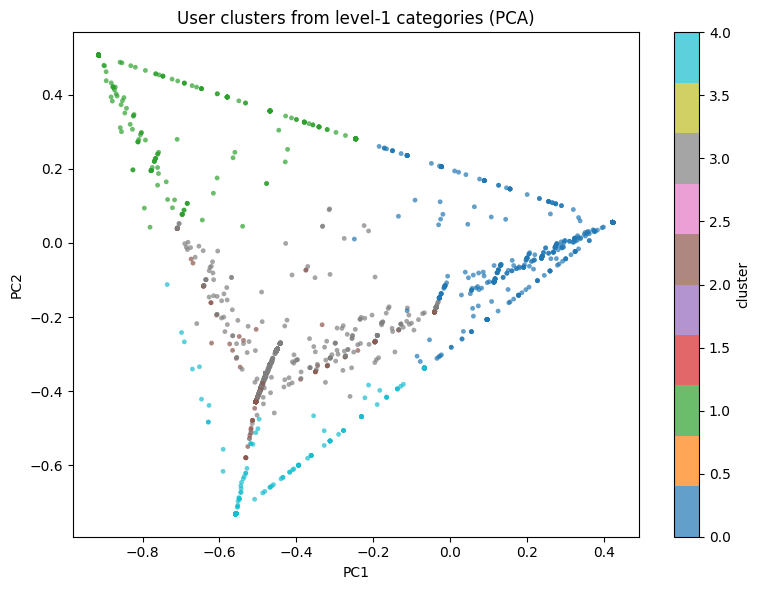

In [38]:
# Step 5c: Plot category clusters (2D projection)
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Project the category vectors to 2D for visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(user_cat_norm)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    coords[:, 0],
    coords[:, 1],
    c=clusters,
    cmap='tab10',
    s=12,
    alpha=0.7,
    edgecolors='none'
 )
plt.title("User clusters from level-1 categories (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

In [39]:
# Step 5d: DBSCAN clustering on level-1 category mix
from sklearn.cluster import DBSCAN

# DBSCAN infers number of clusters; -1 is noise
dbscan = DBSCAN(eps=0.3, min_samples=10)
clusters_dbscan = dbscan.fit_predict(user_cat_norm)

# Count clusters excluding noise (-1)
n_clusters = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_noise = (clusters_dbscan == -1).sum()

# Attach DBSCAN labels to the feature table
df_user_features = df_user_features.merge(
    pd.Series(clusters_dbscan, index=user_cat_norm.index, name='cluster_cat_l1_dbscan'),
    left_on='user_id', right_index=True, how='left'
 )

print(f"✓ DBSCAN clusters found: {n_clusters} (noise: {n_noise})")
df_user_features[['user_id', 'cluster_cat_l1_dbscan']].head()

✓ DBSCAN clusters found: 4 (noise: 88)


,user_id,cluster_cat_l1_dbscan
0,306441847,0.0
1,332550649,0.0
2,370076704,NaN
3,374879087,0.0
4,389518481,NaN


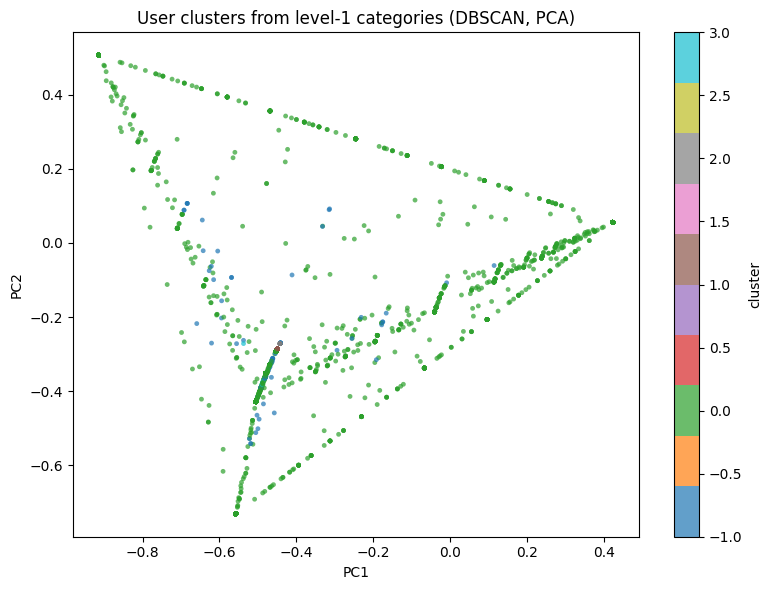

In [40]:
# Step 5e: Plot DBSCAN clusters (2D projection)
# Reuse PCA coords if available; otherwise compute
try:
    coords_dbscan = coords
except NameError:
    pca_dbscan = PCA(n_components=2, random_state=42)
    coords_dbscan = pca_dbscan.fit_transform(user_cat_norm)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    coords_dbscan[:, 0],
    coords_dbscan[:, 1],
    c=clusters_dbscan,
    cmap='tab10',
    s=12,
    alpha=0.7,
    edgecolors='none'
 )
plt.title("User clusters from level-1 categories (DBSCAN, PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="cluster")
plt.tight_layout()
plt.show()

In [41]:
# Step 6: Preview features
print("Preview of user features:")
print(f"\nFirst 10 users:")
df_user_features.head(10)

Preview of user features:

First 10 users:


,user_id,nb_events,nb_sessions,nb_purchases,total_spent,avg_price,nb_categories,purchase_rate,session_intensity,cluster_cat_l1,cluster_cat_l1_dbscan
0,306441847,2,1,0,329.42,164.710000,1,0.0,2.0,1.0,0.0
1,332550649,7,1,0,229.93,32.847143,1,0.0,7.0,3.0,0.0
2,370076704,4,1,0,710.34,177.585000,0,0.0,4.0,NaN,NaN
3,374879087,1,1,0,20.71,20.710000,1,0.0,1.0,3.0,0.0
4,389518481,1,1,0,51.61,51.610000,0,0.0,1.0,NaN,NaN
5,393502154,1,1,0,56.11,56.110000,0,0.0,1.0,NaN,NaN
6,400680280,2,1,0,84.10,42.050000,1,0.0,2.0,0.0,0.0
7,408195133,2,1,0,174.94,87.470000,0,0.0,2.0,NaN,NaN
8,410824220,4,1,0,295.68,73.920000,1,0.0,4.0,2.0,0.0
9,412914047,1,1,0,128.45,128.450000,0,0.0,1.0,NaN,NaN


In [42]:
# Step 7: Save to user_features table
print("Saving to user_features table...")

try:
    # Replace the table (creates if doesn't exist)
    df_user_features.to_sql(
        'user_features',
        engine,
        if_exists='replace',
        index=False
    )
    
    print(f"✓ Successfully saved {len(df_user_features):,} users to user_features table")
    
except Exception as e:
    print(f"✗ Error saving to database: {e}")
    raise

Saving to user_features table...
✓ Successfully saved 20,847 users to user_features table


In [43]:
# Step 8: Verify saved data
print("Verifying saved data...")

df_verify = pd.read_sql_table('user_features', engine)

print(f"✓ Verified: {len(df_verify):,} rows in user_features table")
print(f"\nColumns in table:")
print(list(df_verify.columns))

print(f"\nSample data:")
df_verify.head(10)

Verifying saved data...
✓ Verified: 20,847 rows in user_features table

Columns in table:
['user_id', 'nb_events', 'nb_sessions', 'nb_purchases', 'total_spent', 'avg_price', 'nb_categories', 'purchase_rate', 'session_intensity', 'cluster_cat_l1', 'cluster_cat_l1_dbscan']

Sample data:


,user_id,nb_events,nb_sessions,nb_purchases,total_spent,avg_price,nb_categories,purchase_rate,session_intensity,cluster_cat_l1,cluster_cat_l1_dbscan
0,306441847,2,1,0,329.42,164.710000,1,0.0,2.0,1.0,0.0
1,332550649,7,1,0,229.93,32.847143,1,0.0,7.0,3.0,0.0
2,370076704,4,1,0,710.34,177.585000,0,0.0,4.0,NaN,NaN
3,374879087,1,1,0,20.71,20.710000,1,0.0,1.0,3.0,0.0
4,389518481,1,1,0,51.61,51.610000,0,0.0,1.0,NaN,NaN
5,393502154,1,1,0,56.11,56.110000,0,0.0,1.0,NaN,NaN
6,400680280,2,1,0,84.10,42.050000,1,0.0,2.0,0.0,0.0
7,408195133,2,1,0,174.94,87.470000,0,0.0,2.0,NaN,NaN
8,410824220,4,1,0,295.68,73.920000,1,0.0,4.0,2.0,0.0
9,412914047,1,1,0,128.45,128.450000,0,0.0,1.0,NaN,NaN


## Summary

Successfully created user features with:
- Behavioral features: nb_events, nb_sessions, nb_purchases, session_intensity
- Monetary features: total_spent, avg_price, purchase_rate
- Diversity features: nb_categories

The features have been saved to the `user_features` table in PostgreSQL and are ready for clustering analysis.